# SHRED on ME4OH full-field OFAM3 SST data

In [ ]:
from datetime import date, timedelta

import netCDF4 as nc
import pandas as pd

from Data.load_ohc_l1_data import load_and_filter_ohc
from plotting_functions import plot_sst_map

## Original data

In [39]:
filepath = "Data/OFAM3/temp_ofam3_7d_197901-201412.0p25x0p25.nc"
file_data = nc.Dataset(filepath,'r')

In [40]:
# Extract variables
start_time = date(1979,1,1)
dates = [start_time + timedelta(t) for t in file_data["Time"][:].data]  # Time stored as days since 1979-01-01 00:00:00
lat = file_data["yt_ocean"][:].data  # in degrees N
long = file_data["xt_ocean"][:].data  # in degrees E
depth = file_data["st_ocean"][:].data  # in metres, Z axis
temp = file_data["temp"][:].data  # in degrees C, sea_water_potential_temperature
  # temp.shape is (Time, st_ocean, yt_ocean, xt_ocean)

In [41]:
file_data.close()

In [42]:
temp.shape

(1879, 1, 600, 1440)

In [48]:
for k in range(len(dates)):
    print(f"Running for timestamp {dates[k]}...")
    sst_array = []
    lat_array = []
    long_array = []
    date_array = []
    for i in range(len(lat)):
        for j in range(len(long)):
            sst_array.append(temp[k][0][i][j])
            lat_array.append(lat[i])
            long_array.append(long[j])
            date_array.append(dates[k])
    df = pd.DataFrame({
        "Date": date_array,
        "Latitude": lat_array,
        "Longitude": long_array,
        "SST": sst_array
    })

    # Convert longitude to -180 to 180 format, allows plotting against geopandas world maps
    print("Converting longitudes...")
    df['Longitude'] = df['Longitude'].apply(lambda x: -(360-x) if x > 180 else x)
    # Remove land values
    land_indexes = df.index[df['SST'] == -32768].tolist()
    df = df.loc[~df.index.isin(land_indexes)]

    # Save world file
    # df.to_csv(f"Data/OFAM3/world/{dates[k]}.csv", index=False)

    # Filter to NA basin
    print("Filtering NA basin...")
    na_df = df.loc[(df['Longitude'] >= -80) & (df['Longitude'] <= 0)
                        & (df['Latitude'] <= 60) & (df['Latitude'] >= 0)
                        ].sort_values('Date').reset_index(drop=True)
    na_file_name = f"Data/OFAM3/NA/{dates[k]}.csv"
    # na_df.to_csv(na_file_name, index=False)

    

    break

Running for timestamp 1979-01-04...
Converting longitudes...
Filtering NA basin...


In [49]:
df

,Date,Latitude,Longitude,SST
662,1979-01-04,-74.875,165.625,0.059357
663,1979-01-04,-74.875,165.875,0.131535
664,1979-01-04,-74.875,166.125,-0.237740
665,1979-01-04,-74.875,166.375,-0.340130
666,1979-01-04,-74.875,166.625,-0.145420
...,...,...,...,...
863995,1979-01-04,74.875,-1.125,1.454208
863996,1979-01-04,74.875,-0.875,1.454208
863997,1979-01-04,74.875,-0.625,1.459244
863998,1979-01-04,74.875,-0.375,1.440781


In [60]:
600*1400

840000

In [55]:
depth

array([2.5])

In [59]:
temp[0][0]

array([[-3.2768000e+04, -3.2768000e+04, -3.2768000e+04, ...,
        -3.2768000e+04, -3.2768000e+04, -3.2768000e+04],
       [-3.2768000e+04, -3.2768000e+04, -3.2768000e+04, ...,
        -3.2768000e+04, -3.2768000e+04, -3.2768000e+04],
       [-3.2768000e+04, -3.2768000e+04, -3.2768000e+04, ...,
        -3.2768000e+04, -3.2768000e+04, -3.2768000e+04],
       ...,
       [ 3.7156296e-01,  3.5142136e-01,  2.8763580e-01, ...,
         4.3534470e-01,  4.3534470e-01,  3.9673996e-01],
       [ 2.8763580e-01,  1.7181778e-01,  9.9643707e-02, ...,
         1.0093994e+00,  6.5523148e-01,  4.2359543e-01],
       [ 1.3803520e+00,  1.3753166e+00,  1.4189568e+00, ...,
         1.4592438e+00,  1.4407806e+00,  1.4072075e+00]],
      shape=(600, 1440), dtype=float32)

In [38]:
long.shape

(1440,)

In [39]:
lat.shape

(600,)

In [2]:
DATA_PATH = 'Data/ME4OH_EN411_OFAM3/data/en4.1.1/1993-2014/ofam3-jra55.all.EN.4.1.1.f.profiles.g10.199301.update.extra.anom.199301_201412.nc'
load_and_filter_ohc(DATA_PATH)

(10033,)
(10033,)
(10033, 3)
(10033,)


,Date,Latitude,Longitude,OHC,SSH,WMO Instrument Type,Project name,Platform number
0,1993-01-18,-69.250000,271.950012,0.344897,-1.565600,741,WOD09CTDUS 2512,1354512
1,1993-01-27,-68.949997,290.149994,0.344191,-1.548204,401,WOD09XBTGB 5769,11416169
2,1993-01-27,-68.949997,290.450012,0.344145,-1.545457,401,WOD09XBTGB 5769,11416169
3,1993-01-14,-68.949997,301.049988,0.342160,-1.610157,741,WOD09CTDDE 199,952299
4,1993-01-15,-68.949997,302.049988,0.342066,-1.615955,741,WOD09CTDDE 199,952299
...,...,...,...,...,...,...,...,...
6782,1993-01-25,73.849998,31.250000,0.347506,-0.719016,741,WOD09CTDNO 5343,464243
6783,1993-01-18,74.050003,23.049999,0.347372,-0.679647,741,WOD09CTDNO 5343,464243
6784,1993-01-19,74.050003,25.049999,0.348112,-0.609149,741,WOD09CTDNO 5343,464243
6785,1993-01-24,74.050003,27.049999,0.347161,-0.657369,741,WOD09CTDNO 5343,464243


# Example visualisation

In [20]:
date = '2012-06-28'  
date = '1979-01-04'
df = pd.read_csv(f"Data/OFAM3/NA/{date}.csv")
# df['Date'] = pd.to_datetime('1979-01-04')

In [21]:
df

,Latitude,Longitude,SST
0,0.125,-49.125,30.328075
1,0.125,-48.875,30.257576
2,0.125,-48.625,30.089725
3,0.125,-48.375,29.963837
4,0.125,-48.125,29.764091
...,...,...,...
59058,59.875,-1.125,8.049103
59059,59.875,-0.875,8.050781
59060,59.875,-0.625,8.028961
59061,59.875,-0.375,7.899715


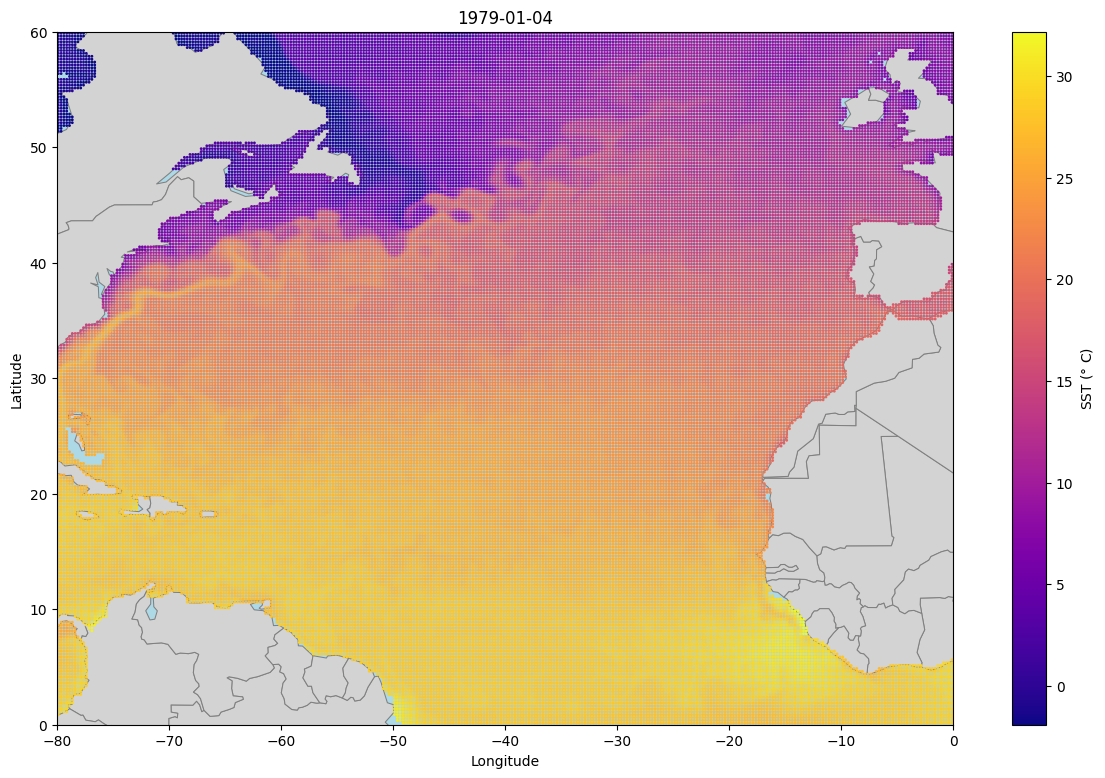

In [22]:
plot_sst_map(df, date, min(df.SST), max(df.SST), basin='NA')